In [ ]:
# Install required dependencies for YOLO-based model training (Ultralytics)
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive to access datasets and save outputs
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Define dataset directory structure and initialize training/testing folders
import os

base_dir = "/content/drive/MyDrive/TBBR"

npy_dir = os.path.join(base_dir, "npy")
ann_dir = os.path.join(base_dir, "annotations")
img_train_dir = os.path.join(base_dir, "images/train")
img_test_dir  = os.path.join(base_dir, "images/test")
lab_train_dir = os.path.join(base_dir, "labels/train")
lab_test_dir  = os.path.join(base_dir, "labels/test")

# Create folders if they don't exist
for d in [img_train_dir, img_test_dir, lab_train_dir, lab_test_dir]:
    os.makedirs(d, exist_ok=True)

print("Folders ready:")
print("npy_dir:", npy_dir)
print("ann_dir:", ann_dir)
print("img_train_dir:", img_train_dir)
print("img_test_dir:", img_test_dir)
print("lab_train_dir:", lab_train_dir)
print("lab_test_dir:", lab_test_dir)


Folders ready:
npy_dir: /content/drive/MyDrive/TBBR/npy
ann_dir: /content/drive/MyDrive/TBBR/annotations
img_train_dir: /content/drive/MyDrive/TBBR/images/train
img_test_dir: /content/drive/MyDrive/TBBR/images/test
lab_train_dir: /content/drive/MyDrive/TBBR/labels/train
lab_test_dir: /content/drive/MyDrive/TBBR/labels/test


In [ ]:
# Load and verify training and testing image paths from dataset directories
import glob

train_imgs = glob.glob("/content/drive/MyDrive/TBBR/images/train/**/*.png", recursive=True)
test_imgs  = glob.glob("/content/drive/MyDrive/TBBR/images/test/**/*.png", recursive=True)

print("Train PNGs:", len(train_imgs))
print("Test PNGs :", len(test_imgs))

Train PNGs: 2181
Test PNGs : 203


In [ ]:
# Check GPU availability and verify CUDA configuration for model training
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: NVIDIA L4


In [ ]:
# Initialize YOLOv8 model and train baseline configuration on thermal bridge dataset
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    # Save permanently to Drive
    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v8n_light_baseline_640_b16_adamw",
    exist_ok=False,

    # Training length (lighter / faster for tuning)
    epochs=50,
    patience=10,

    # Image & batch (main speed lever)
    imgsz=640,
    batch=16,
    workers=2,

    # Optimizer & LR (simple + stable)
    optimizer="AdamW",
    lr0=1e-3,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    # Thermal-friendly aug (minimal)
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    flipud=0.0,
    fliplr=0.5,

    # Keep off for true lightweight baseline
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    # Logs
    val=True,
    plots=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8n_light_baseline_640_b16_adamw, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

In [ ]:
!ls "/content/drive/MyDrive/TBBR/results_revision/v8n_light_baseline_640_b16_adamw/weights"

best.pt  last.pt


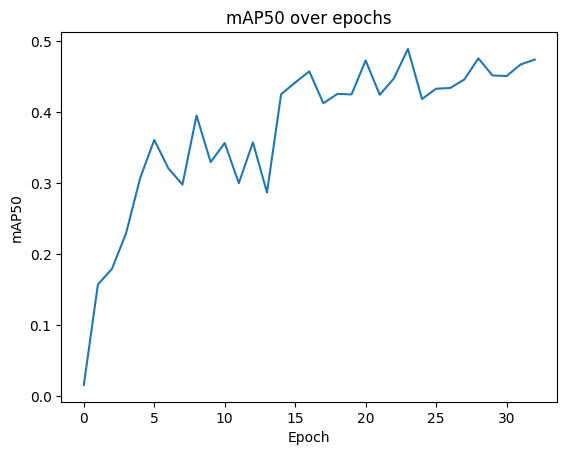

In [ ]:
# Load trained model and analyze training performance metrics (mAP over epochs)
from ultralytics import YOLO
best = YOLO("/content/drive/MyDrive/TBBR/results_revision/v8n_light_baseline_640_b16_adamw/weights/best.pt")

import pandas as pd

run_dir = "/content/drive/MyDrive/TBBR/results_revision/v8n_light_baseline_640_b16_adamw"
df = pd.read_csv(f"{run_dir}/results.csv")

df.tail(5)  # last 5 epochs that were logged

import pandas as pd
import matplotlib.pyplot as plt

run_dir = "/content/drive/MyDrive/TBBR/results_revision/v8n_light_baseline_640_b16_adamw"
df = pd.read_csv(f"{run_dir}/results.csv")

plt.figure()
plt.plot(df["metrics/mAP50(B)"])
plt.title("mAP50 over epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.show()

**Let's Hyper Tune!**

In [ ]:
# Hyperparameter tuning run (single change + faster)
# Change: lower lr0 from 1e-3 -> 5e-4
# Also: fewer epochs (enough for comparison) + new run name so nothing overwrites

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    # Save permanently to Drive (new folder for this trial)
    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v8n_tune_lr5e-4_640_b16_adamw",
    exist_ok=False,

    # Training length (tuning)
    epochs=35,
    patience=8,

    # Image & batch
    imgsz=640,
    batch=16,
    workers=2,

    # Optimizer & LR (TUNED)
    optimizer="AdamW",
    lr0=5e-4,         # ✅ tuned lower LR
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    # Thermal-friendly aug (minimal)
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    flipud=0.0,
    fliplr=0.5,

    # Keep off for lightweight baseline
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    # Logs
    val=True,
    plots=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8n_tune_lr5e-4_640_b16_adamw, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d2ff398b6b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

**Let's compare these two!**

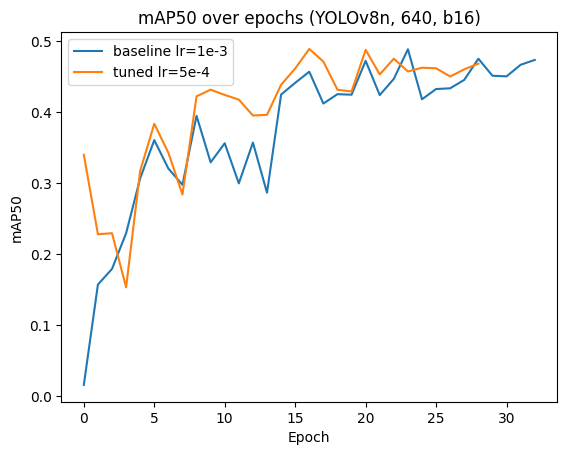

Baseline best mAP50: 0.48877
Tuned best mAP50: 0.48927
Baseline best mAP50-95: 0.24769
Tuned best mAP50-95: 0.24188


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

base_dir  = "/content/drive/MyDrive/TBBR/results_revision/v8n_light_baseline_640_b16_adamw"
tuned_dir = "/content/drive/MyDrive/TBBR/results_revision/v8n_tune_lr5e-4_640_b16_adamw"

df_base  = pd.read_csv(f"{base_dir}/results.csv")
df_tuned = pd.read_csv(f"{tuned_dir}/results.csv")

plt.figure()
plt.plot(df_base["metrics/mAP50(B)"], label="baseline lr=1e-3")
plt.plot(df_tuned["metrics/mAP50(B)"], label="tuned lr=5e-4")
plt.title("mAP50 over epochs (YOLOv8n, 640, b16)")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.legend()
plt.show()

print("Baseline best mAP50:", df_base["metrics/mAP50(B)"].max())
print("Tuned best mAP50:", df_tuned["metrics/mAP50(B)"].max())

print("Baseline best mAP50-95:", df_base["metrics/mAP50-95(B)"].max())
print("Tuned best mAP50-95:", df_tuned["metrics/mAP50-95(B)"].max())

In [ ]:
# YOLOv8n Lightweight 512 Experiment
# Only change from final baseline: imgsz 640 -> 512

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    # Save permanently to Drive (new folder)
    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v8n_light_512_b16_adamw_lr5e-4",
    exist_ok=False,

    # Training length (same as tuned 640 for fair comparison)
    epochs=35,
    patience=8,

    # Image & batch (ONLY change here)
    imgsz=512,              # 🔥 lightweight resolution
    batch=16,
    workers=2,

    # Optimizer & LR (locked final config)
    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    # Thermal-friendly aug (unchanged)
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    flipud=0.0,
    fliplr=0.5,

    # Keep off for true lightweight baseline
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    # Logs
    val=True,
    plots=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8n_light_512_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d2e0510be00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

  baseline 640 lr=1e-3 | best mAP50 = 0.4888 | best mAP50-95 = 0.2477
     tuned 640 lr=5e-4 | best mAP50 = 0.4893 | best mAP50-95 = 0.2419
     light 512 lr=5e-4 | best mAP50 = 0.4586 | best mAP50-95 = 0.2375


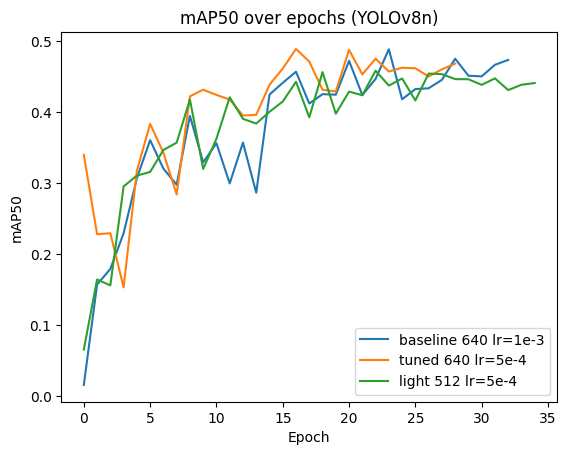

In [ ]:
# Compare multiple training configurations and visualize performance (mAP) across experiments
import pandas as pd
import matplotlib.pyplot as plt

# --- Run folders ---
dir_base640  = "/content/drive/MyDrive/TBBR/results_revision/v8n_light_baseline_640_b16_adamw"      # lr=1e-3
dir_tuned640 = "/content/drive/MyDrive/TBBR/results_revision/v8n_tune_lr5e-4_640_b16_adamw"         # lr=5e-4
dir_light512 = "/content/drive/MyDrive/TBBR/results_revision/v8n_light_512_b16_adamw_lr5e-4"        # lr=5e-4, 512

# --- Load CSVs ---
df_base  = pd.read_csv(f"{dir_base640}/results.csv")
df_tuned = pd.read_csv(f"{dir_tuned640}/results.csv")
df_512   = pd.read_csv(f"{dir_light512}/results.csv")

# --- Print best metrics ---
def best_metrics(df, tag):
    best_map50 = df["metrics/mAP50(B)"].max()
    best_map95 = df["metrics/mAP50-95(B)"].max()
    print(f"{tag:>22} | best mAP50 = {best_map50:.4f} | best mAP50-95 = {best_map95:.4f}")

best_metrics(df_base,  "baseline 640 lr=1e-3")
best_metrics(df_tuned, "tuned 640 lr=5e-4")
best_metrics(df_512,   "light 512 lr=5e-4")

# --- Plot mAP50 curves ---
plt.figure()
plt.plot(df_base["metrics/mAP50(B)"],  label="baseline 640 lr=1e-3")
plt.plot(df_tuned["metrics/mAP50(B)"], label="tuned 640 lr=5e-4")
plt.plot(df_512["metrics/mAP50(B)"],   label="light 512 lr=5e-4")

plt.title("mAP50 over epochs (YOLOv8n)")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.legend()
plt.show()

In [ ]:
# === Summary: best mAP50 and final epoch for each run ===
summary = []

for label, csv_path in runs:
    df = load_results(csv_path)
    df.columns = [c.strip() for c in df.columns]

    map50_col = next((c for c in ["metrics/mAP50(B)", "metrics/mAP50", "mAP50"] if c in df.columns), None)
    map5095_col = next((c for c in ["metrics/mAP50-95(B)", "metrics/mAP50-95", "mAP50-95"] if c in df.columns), None)

    best_idx = df[map50_col].idxmax()
    best_map50 = df.loc[best_idx, map50_col]
    best_map5095 = df.loc[best_idx, map5095_col] if map5095_col else None

    summary.append({
        "run": label,
        "best_epoch": int(df.loc[best_idx, "epoch"]) if "epoch" in df.columns else int(best_idx),
        "best_mAP50": float(best_map50),
        "best_mAP50-95": float(best_map5095) if best_map5095 is not None else None,
    })

summary_df = pd.DataFrame(summary).sort_values("best_mAP50", ascending=False)
display(summary_df)

,run,best_epoch,best_mAP50,best_mAP50-95
1,tuned 640 lr=5e-4,17,0.48927,0.23404
0,baseline 640 lr=1e-3,24,0.48877,0.24769
2,light 512 AdamW lr=5e-4,23,0.45858,0.23659




---



In [ ]:
# YOLOv8s (small) training: 640, AdamW, lr=5e-4, 35 epochs, batch 16
!yolo detect train \
  model=yolov8s.pt \
  data=/content/drive/MyDrive/TBBR/dataset.yaml \
  imgsz=640 \
  epochs=35 \
  batch=16 \
  optimizer=AdamW \
  lr0=0.0005 \
  weight_decay=0.0005 \
  cos_lr=True \
  patience=8 \
  workers=2 \
  seed=0 \
  deterministic=True \
  close_mosaic=10 \
  hsv_h=0.0 hsv_s=0.0 hsv_v=0.1 \
  translate=0.1 scale=0.5 \
  fliplr=0.5 flipud=0.0 \
  erasing=0.4 \
  project=/content/drive/MyDrive/TBBR/results_revision \
  name=v8s_640_b16_adamw_lr5e-4

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8s_640_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

In [ ]:
# Medium model (YOLOv8m) with the SAME parameters as your v8s run
# Assumes you already have ultralytics installed in Colab:
# !pip install ultralytics

from ultralytics import YOLO

DATA_YAML = "/content/drive/MyDrive/TBBR/dataset.yaml"
PROJECT_DIR = "/content/drive/MyDrive/TBBR/results_revision"
RUN_NAME = "v8m_640_b16_adamw_lr5e-4"

model = YOLO("yolov8m.pt")  # medium pretrained weights

results = model.train(
    data=DATA_YAML,
    imgsz=640,
    epochs=35,
    batch=16,
    optimizer="AdamW",
    lr0=5e-4,
    cos_lr=True,
    patience=8,
    seed=0,
    deterministic=True,
    workers=2,
    plots=True,
    val=True,
    project=PROJECT_DIR,
    name=RUN_NAME,
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8m_640_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

In [ ]:
# Summarize and compare best-performing epochs and metrics across multiple YOLO model variants
runs = [
    "v8n_light_baseline_640_b16_adamw",
    "v8s_640_b16_adamw_lr5e-4",
    "v8m_640_b16_adamw_lr5e-4"
]

import pandas as pd
import yaml
import os

base_dir = "/content/drive/MyDrive/TBBR/results_revision"

summary_rows = []

for run in runs:
    run_path = os.path.join(base_dir, run)

    # Load results.csv
    df = pd.read_csv(os.path.join(run_path, "results.csv"))

    # Get best epoch based on mAP50
    best_idx = df["metrics/mAP50(B)"].idxmax()

    best_epoch = int(df.loc[best_idx, "epoch"])
    best_map50 = df.loc[best_idx, "metrics/mAP50(B)"]
    best_map5095 = df.loc[best_idx, "metrics/mAP50-95(B)"]

    # Load args.yaml to get model info
    with open(os.path.join(run_path, "args.yaml"), "r") as f:
        args = yaml.safe_load(f)

    model_name = args["model"]

    summary_rows.append([
        run,
        model_name,
        best_epoch,
        round(best_map50, 4),
        round(best_map5095, 4)
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Run Name", "Model", "Best Epoch", "mAP50", "mAP50-95"]
)

summary_df

,Run Name,Model,Best Epoch,mAP50,mAP50-95
0,v8n_light_baseline_640_b16_adamw,/content/drive/MyDrive/TBBR/results_revision/v...,24,0.4888,0.2477
1,v8s_640_b16_adamw_lr5e-4,yolov8s.pt,14,0.5255,0.2630
2,v8m_640_b16_adamw_lr5e-4,yolov8m.pt,23,0.5354,0.3040


In [ ]:
# Compare multiple YOLO runs (v8n / v8s / v8m) in ONE table:
# - Precision, Recall, F1
# - mAP50, mAP50-95
# - speed (pre/infer/post ms per image)
# - plus "train wall time" parsed from results.csv (works if that file exists)

!pip -q install ultralytics

from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import numpy as np
import yaml # Added for YAML inspection

# -------------------------
# USER SETTINGS
# -------------------------
project_dir = Path("/content/drive/MyDrive/TBBR/results_revision")  # <-- change if needed
data_yaml   = "/content/drive/MyDrive/TBBR/dataset.yaml"
imgsz       = 640
split       = "val"  # "val" or "test" # Changed 'test' to 'val'

run_names = [
    "v8m_640_b16_adamw_lr5e-4",
    "v8s_640_b16_adamw_lr5e-4",
    "v8n_light_baseline_640_b16_adamw",
]

# -------------------------
# Helpers
# -------------------------
def find_best_pt(run_dir: Path) -> Path:
    p = run_dir / "weights" / "best.pt"
    if p.exists():
        return p
    # fallback: sometimes training saved directly elsewhere
    candidates = list(run_dir.rglob("best.pt"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"Could not find best.pt under {run_dir}")

def parse_train_wall_time_hours(run_dir: Path):
    """
    Attempts to estimate train wall time by reading results.csv:
    - If it has a time column (varies by ultralytics version), use last value.
    - Otherwise: use file modified times as a rough fallback.
    """
    results_csv = run_dir / "results.csv"
    if results_csv.exists():
        df = pd.read_csv(results_csv)
        # try common possibilities
        for col in ["time", "train/time", "epoch_time", "metrics/time", "dt"]:
            if col in df.columns:
                # Some versions store seconds per epoch; others store cumulative hours.
                vals = df[col].dropna().values
                if len(vals) == 0:
                    break
                last = float(vals[-1])
                # Heuristic: if last is small (<200) and looks like seconds per epoch, multiply by epochs
                if col in ["dt", "epoch_time"] and last < 200:
                    return float(vals.sum()) / 3600.0
                # If it looks like hours already (often < 50), keep it
                if last < 200:
                    return last
                # else assume seconds cumulative
                return last / 3600.0

        # If no explicit time col, estimate from timestamps in CSV rows (not always present)
        # fallback: just return NaN
        return np.nan

    # last fallback: use modified time difference between first/last weights (rough)
    wdir = run_dir / "weights"
    last_pt = wdir / "last.pt"
    best_pt = wdir / "best.pt"
    if last_pt.exists() and best_pt.exists():
        t0 = min(last_pt.stat().st_mtime, best_pt.stat().st_mtime)
        t1 = max(last_pt.stat().st_mtime, best_pt.stat().st_mtime)
        return (t1 - t0) / 3600.0

    return np.nan

def eval_one(weights_path: Path):
    model = YOLO(str(weights_path))
    r = model.val(
        data=data_yaml,
        imgsz=imgsz,
        split=split,
        conf=0.001,
        iou=0.6,
        plots=False,
        save_json=False,
        verbose=False
    )
    mp    = float(r.box.mp)
    mr    = float(r.box.mr)
    map50 = float(r.box.map50)
    map95 = float(r.box.map)

    f1 = (2 * mp * mr / (mp + mr)) if (mp + mr) > 0 else 0.0

    speed = getattr(r, "speed", None) or {}
    pre_ms  = float(speed.get("preprocess", np.nan))
    inf_ms  = float(speed.get("inference",  np.nan))
    post_ms = float(speed.get("postprocess", np.nan))

    return {
        "Precision(mean)": mp,
        "Recall(mean)": mr,
        "F1(meanP/meanR)": f1,
        "mAP50": map50,
        "mAP50-95": map95,
        "preprocess_ms/img": pre_ms,
        "inference_ms/img": inf_ms,
        "postprocess_ms/img": post_ms,
        "params(M)": getattr(model.model, "np", np.nan) / 1e6 if hasattr(model, "model") else np.nan,  # may be NaN
    }

# -------------------------
# Run comparison
# -------------------------
# First, let's verify the dataset.yaml content
try:
    with open(data_yaml, 'r') as f:
        dataset_content = yaml.safe_load(f)
    print(f"Content of {data_yaml}:\n{yaml.dump(dataset_content, indent=2)}")
    if split not in dataset_content:
        print(f"ERROR: '{split}' key not found in {data_yaml}. Available keys: {list(dataset_content.keys())}")
    elif dataset_content[split] is None or dataset_content[split] == '':
        print(f"ERROR: '{split}' path is empty or None in {data_yaml}.")
    else:
        print(f"'{split}' path in {data_yaml} is: {dataset_content[split]}")
        # You might want to add a check here to verify if the path actually exists

except FileNotFoundError:
    print(f"ERROR: dataset.yaml not found at {data_yaml}")
except yaml.YAMLError as e:
    print(f"ERROR: Could not parse {data_yaml}. YAML error: {e}")
except Exception as e:
    print(f"An unexpected error occurred while reading {data_yaml}: {e}")

rows = []
for run in run_names:
    run_dir = project_dir / run
    best_pt = find_best_pt(run_dir)
    metrics = eval_one(best_pt)
    train_h = parse_train_wall_time_hours(run_dir)

    rows.append({
        "run_name": run,
        "best_pt": str(best_pt),
        "epochs_ran": int(pd.read_csv(run_dir / "results.csv").shape[0]) if (run_dir / "results.csv").exists() else np.nan,
        "train_wall_time_hr (est)": train_h,
        **metrics
    })

df = pd.DataFrame(rows)

# Make it easier to read: sort by mAP50-95 descending
df = df.sort_values("mAP50-95", ascending=False).reset_index(drop=True)

print("=== Model Comparison Table ===")
display(df)

# Optional: save to CSV in Drive
out_csv = project_dir / "model_comparison_metrics.csv"
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

Content of /content/drive/MyDrive/TBBR/dataset.yaml:
names:
  0: thermal_bridge
path: /content/drive/MyDrive/TBBR
train: images/train
val: images/test

'val' path in /content/drive/MyDrive/TBBR/dataset.yaml is: images/test
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 3.0±6.2 ms, read: 388.2±317.4 MB/s, size: 2987.8 KB)
val: Scanning /content/drive/MyDrive/TBBR/labels/test/Flug1_105.cache... 203 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 203/203 85.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.3it/s 5.6s
                   all        203       1313      0.737      0.471      0.552      0.312
Speed: 0.7ms preprocess, 7.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22

,run_name,best_pt,epochs_ran,train_wall_time_hr (est),Precision(mean),Recall(mean),F1(meanP/meanR),mAP50,mAP50-95,preprocess_ms/img,inference_ms/img,postprocess_ms/img,params(M)
0,v8m_640_b16_adamw_lr5e-4,/content/drive/MyDrive/TBBR/results_revision/v...,31,1.193242,0.736537,0.470548,0.574236,0.551998,0.311938,0.696606,7.238189,0.863823,NaN
1,v8s_640_b16_adamw_lr5e-4,/content/drive/MyDrive/TBBR/results_revision/v...,35,1.325972,0.676394,0.467631,0.552965,0.518545,0.285221,0.658857,3.559174,0.926826,NaN
2,v8n_light_baseline_640_b16_adamw,/content/drive/MyDrive/TBBR/results_revision/v...,33,1.254503,0.610539,0.465347,0.528146,0.504960,0.251764,0.659564,1.750551,0.844781,NaN


Saved: /content/drive/MyDrive/TBBR/results_revision/model_comparison_metrics.csv


In [ ]:
# Train YOLOv8m model with moderate augmentation to improve detection performance
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",
    imgsz=640,
    batch=16,
    epochs=35,
    optimizer="AdamW",
    lr0=5e-4,
    cos_lr=True,
    patience=8,
    seed=0,
    deterministic=True,
    workers=2,
    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v8m_640_b16_adamw_lr5e-4_aug_mod",

    # ---- Moderate augmentation knobs ----
    augment=True,
    hsv_h=0.015,     # keep yours (already moderate)
    hsv_s=0.7,       # keep yours
    hsv_v=0.4,       # keep yours
    fliplr=0.5,
    translate=0.1,
    scale=0.5,
    degrees=5.0,     # add small rotation
    shear=0.0,
    perspective=0.0005,  # tiny perspective
    mosaic=1.0,
    close_mosaic=10,
    mixup=0.0,
    copy_paste=0.0
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8m_640_b16_adamw_lr5e-4_aug_mod, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, over

In [ ]:
# Train YOLOv8m model with moderate augmentation to improve detection performance
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",
    imgsz=640,
    epochs=35,
    batch=16,
    optimizer="AdamW",
    lr0=5e-4,
    cos_lr=True,
    weight_decay=5e-4,
    patience=8,
    workers=2,
    seed=0,
    deterministic=True,

    # mild, realistic augmentation
    augment=True,
    auto_augment=None,   # IMPORTANT: disable randaugment
    degrees=2.0,
    translate=0.05,
    scale=0.30,
    shear=0.0,
    perspective=0.0,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.5,
    mixup=0.0,
    copy_paste=0.0,

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v8m_640_b16_adamw_lr5e-4_aug_mild",
    pretrained=True,
    plots=True,
    val=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=2.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=v8m_640_b16_adamw_lr5e-4_aug_mild, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_ma

In [ ]:
# Train YOLOv8l model with moderate augmentation to improve detection performance
!pip -q install ultralytics==8.4.18

from ultralytics import YOLO

model = YOLO("yolov8l.pt")  # LARGE

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",
    imgsz=640,
    epochs=35,
    patience=8,
    batch=16,                 # if OOM -> set to 8 or 4
    optimizer="AdamW",
    lr0=5e-4,
    cos_lr=True,
    weight_decay=5e-4,
    workers=2,
    seed=0,
    deterministic=True,
    pretrained=True,
    plots=True,
    val=True,
    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v8l_640_b16_adamw_lr5e-4"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.19 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=No

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x789e4d061c40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv11 nano model under baseline settings for comparison with YOLOv8 experiments
from ultralytics import YOLO

# Load YOLO11 nano
model = YOLO("yolo11n.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    # Save permanently to Drive
    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v11n_640_b16_adamw_lr5e-4",
    exist_ok=False,

    # Training length
    epochs=35,
    patience=8,

    # Image & batch
    imgsz=640,
    batch=16,
    workers=2,

    # Optimizer & LR
    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    # Keep augmentation minimal (baseline consistency)
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    # Logs
    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d421803c530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv11 small model under baseline settings for performance comparison across architectures
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v11s_640_b16_adamw_lr5e-4",
    exist_ok=False,

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v11s_640_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d42902c8380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv11 medium model under baseline settings for performance comparison across architectures
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v11m_640_b16_adamw_lr5e-4",
    exist_ok=False,

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v11m_640_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d440f5db080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv11 large model under baseline settings for performance comparison across architectures
from ultralytics import YOLO

model = YOLO("yolo11l.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v11l_640_b16_adamw_lr5e-4",
    exist_ok=False,

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,   # if CUDA OOM -> change to 8 (or 4)
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791925bfa900>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

=== Ranked by mAP50 ===


,Model,Best Epoch,Precision,Recall,mAP50,mAP50-95,F1
5,v11s,16,0.55297,0.52399,0.54674,0.27853,0.538090
2,v8m,22,0.72008,0.45773,0.53536,0.30396,0.559687
6,v11m,22,0.66106,0.50267,0.53218,0.28226,0.571086
7,v11l,25,0.67443,0.47525,0.53019,0.27764,0.557586
1,v8s,13,0.65144,0.47982,0.52549,0.26297,0.552612
4,v11n,29,0.67404,0.44631,0.50828,0.25454,0.537030
3,v8l,16,0.59971,0.44554,0.49561,0.26474,0.511255
0,v8n,23,0.58642,0.44478,0.48877,0.24769,0.505873



=== Ranked by mAP50-95 ===


,Model,Best Epoch,Precision,Recall,mAP50,mAP50-95,F1
2,v8m,22,0.72008,0.45773,0.53536,0.30396,0.559687
6,v11m,22,0.66106,0.50267,0.53218,0.28226,0.571086
5,v11s,16,0.55297,0.52399,0.54674,0.27853,0.538090
7,v11l,25,0.67443,0.47525,0.53019,0.27764,0.557586
3,v8l,16,0.59971,0.44554,0.49561,0.26474,0.511255
1,v8s,13,0.65144,0.47982,0.52549,0.26297,0.552612
4,v11n,29,0.67404,0.44631,0.50828,0.25454,0.537030
0,v8n,23,0.58642,0.44478,0.48877,0.24769,0.505873


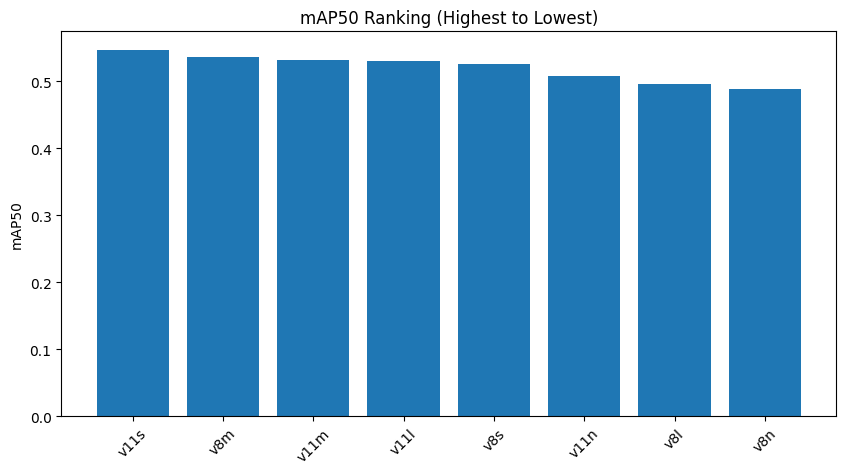

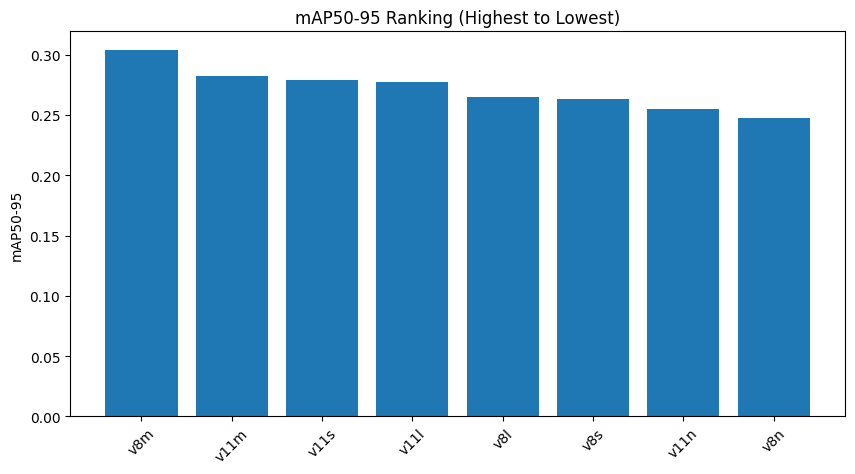

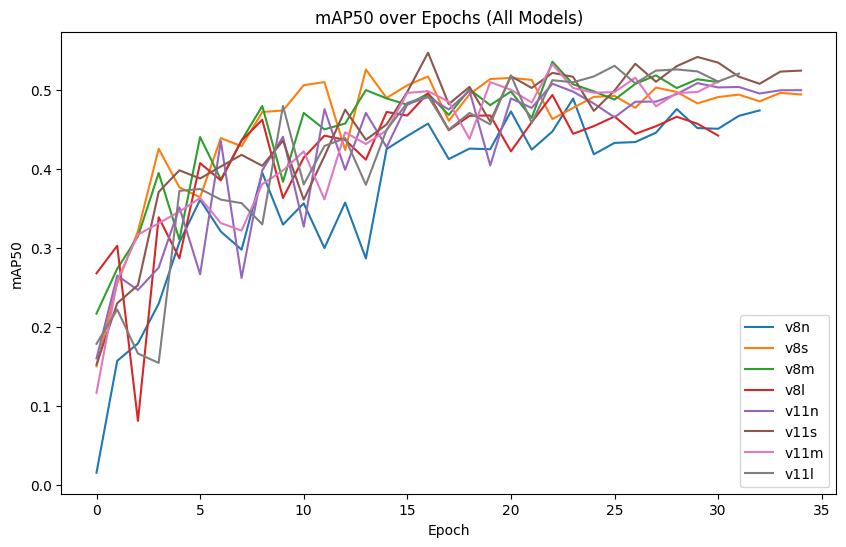

In [ ]:
# Summarize and rank YOLOv8 and YOLOv11 model variants using key evaluation metrics
import pandas as pd
import os
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/TBBR/results_revision"

runs = {
    "v8n": "v8n_light_baseline_640_b16_adamw",
    "v8s": "v8s_640_b16_adamw_lr5e-4",
    "v8m": "v8m_640_b16_adamw_lr5e-4",
    "v8l": "v8l_640_b16_adamw_lr5e-4",

    "v11n": "v11n_640_b16_adamw_lr5e-4",
    "v11s": "v11s_640_b16_adamw_lr5e-4",
    "v11m": "v11m_640_b16_adamw_lr5e-4",
    "v11l": "v11l_640_b16_adamw_lr5e-4",
}

results = []

for name, folder in runs.items():
    run_dir = os.path.join(base_path, folder)
    csv_path = os.path.join(run_dir, "results.csv")

    if not os.path.exists(csv_path):
        print(f"Missing: {name}")
        continue

    df = pd.read_csv(csv_path)

    best_idx = df["metrics/mAP50(B)"].idxmax()
    best_row = df.loc[best_idx]

    precision = best_row["metrics/precision(B)"]
    recall = best_row["metrics/recall(B)"]

    results.append({
        "Model": name,
        "Best Epoch": int(best_idx),
        "Precision": precision,
        "Recall": recall,
        "mAP50": best_row["metrics/mAP50(B)"],
        "mAP50-95": best_row["metrics/mAP50-95(B)"],
        "F1": 2 * (precision * recall) / (precision + recall + 1e-9)
    })

summary_df = pd.DataFrame(results)

# ----------- RANKED TABLES -----------

rank_map50 = summary_df.sort_values("mAP50", ascending=False)
rank_map5095 = summary_df.sort_values("mAP50-95", ascending=False)

print("=== Ranked by mAP50 ===")
display(rank_map50)

print("\n=== Ranked by mAP50-95 ===")
display(rank_map5095)

# ----------- BAR PLOTS (RANKED) -----------

plt.figure(figsize=(10,5))
plt.bar(rank_map50["Model"], rank_map50["mAP50"])
plt.xticks(rotation=45)
plt.ylabel("mAP50")
plt.title("mAP50 Ranking (Highest to Lowest)")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(rank_map5095["Model"], rank_map5095["mAP50-95"])
plt.xticks(rotation=45)
plt.ylabel("mAP50-95")
plt.title("mAP50-95 Ranking (Highest to Lowest)")
plt.show()

# ----------- EPOCH CURVES -----------

plt.figure(figsize=(10,6))

for name, folder in runs.items():
    run_dir = os.path.join(base_path, folder)
    csv_path = os.path.join(run_dir, "results.csv")

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        plt.plot(df["metrics/mAP50(B)"], label=name)

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("mAP50 over Epochs (All Models)")
plt.show()

In [ ]:
# Train YOLOv26 nano model under baseline settings for cross-generation model comparison
from ultralytics import YOLO

# v26n model (update the filename if yours is different)
model = YOLO("yolo26n.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v26n_640_b16_adamw_lr5e-4",
    exist_ok=False,  # set True if you want to overwrite an existing run folder

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,   # if CUDA OOM -> change to 8 (or 4)
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79cc837a5dc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv26 small model under baseline settings for cross-generation model comparison
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v26s_640_b16_adamw_lr5e-4",
    exist_ok=False,

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,   # if CUDA OOM -> change to 8 (or 4)
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v26s_640_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79ce79d72630>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv26 medium model under baseline settings for cross-generation model comparison
from ultralytics import YOLO

model = YOLO("yolo26m.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v26m_640_b16_adamw_lr5e-4",
    exist_ok=False,

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,   # if CUDA OOM -> change to 8 (or 4)
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v26m_640_b16_adamw_lr5e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79cb637f7f80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Train YOLOv26 large model under baseline settings for cross-generation model comparison
from ultralytics import YOLO

model = YOLO("yolo26l.pt")

model.train(
    data="/content/drive/MyDrive/TBBR/dataset.yaml",

    project="/content/drive/MyDrive/TBBR/results_revision",
    name="v26l_640_b16_adamw_lr5e-4",
    exist_ok=False,

    epochs=35,
    patience=8,

    imgsz=640,
    batch=16,   # if CUDA OOM -> change to 8 (or 4)
    workers=2,

    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    warmup_epochs=2.0,
    warmup_bias_lr=0.1,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,
    fliplr=0.5,
    flipud=0.0,
    mixup=0.0,
    copy_paste=0.0,
    auto_augment=None,

    val=True,
    plots=True,
    deterministic=True,
    seed=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/TBBR/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb2e9606030>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

=== Ranked by mAP50 ===


,Model,Best Epoch,Precision,Recall,mAP50,mAP50-95,F1
5,v11s,17,0.55297,0.52399,0.54674,0.27853,0.538090
2,v8m,23,0.72008,0.45773,0.53536,0.30396,0.559687
6,v11m,23,0.66106,0.50267,0.53218,0.28226,0.571086
7,v11l,26,0.67443,0.47525,0.53019,0.27764,0.557586
1,v8s,14,0.65144,0.47982,0.52549,0.26297,0.552612
10,v26m,12,0.56827,0.48018,0.51684,0.23814,0.520524
4,v11n,30,0.67404,0.44631,0.50828,0.25454,0.537030
11,v26l,12,0.70280,0.41243,0.49624,0.25650,0.519813
3,v8l,17,0.59971,0.44554,0.49561,0.26474,0.511255
9,v26s,19,0.59514,0.47449,0.49417,0.25494,0.528011



=== Ranked by mAP50-95 ===


,Model,Best Epoch,Precision,Recall,mAP50,mAP50-95,F1
2,v8m,23,0.72008,0.45773,0.53536,0.30396,0.559687
6,v11m,23,0.66106,0.50267,0.53218,0.28226,0.571086
5,v11s,17,0.55297,0.52399,0.54674,0.27853,0.538090
7,v11l,26,0.67443,0.47525,0.53019,0.27764,0.557586
3,v8l,17,0.59971,0.44554,0.49561,0.26474,0.511255
1,v8s,14,0.65144,0.47982,0.52549,0.26297,0.552612
11,v26l,12,0.70280,0.41243,0.49624,0.25650,0.519813
9,v26s,19,0.59514,0.47449,0.49417,0.25494,0.528011
4,v11n,30,0.67404,0.44631,0.50828,0.25454,0.537030
0,v8n,24,0.58642,0.44478,0.48877,0.24769,0.505873


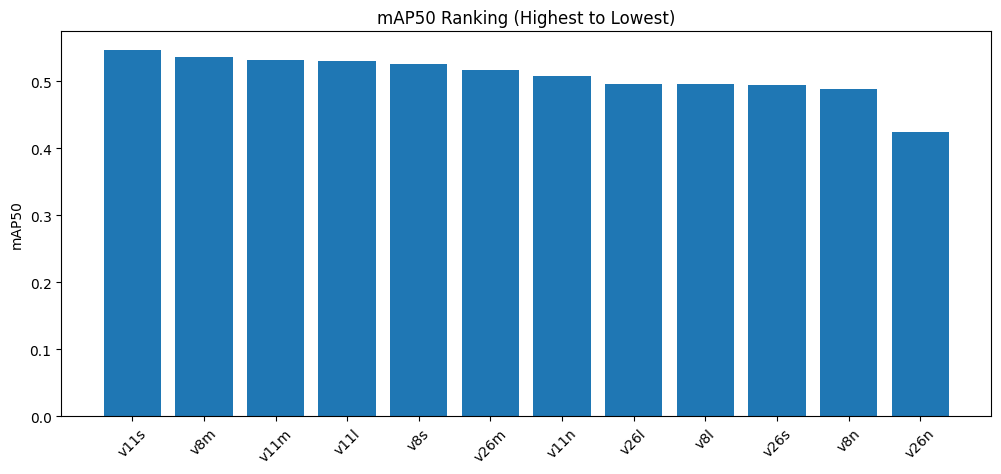

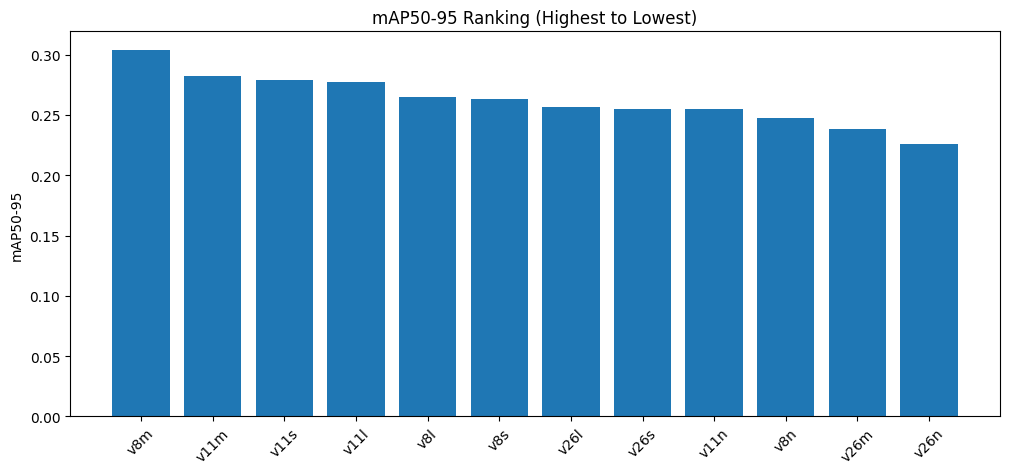

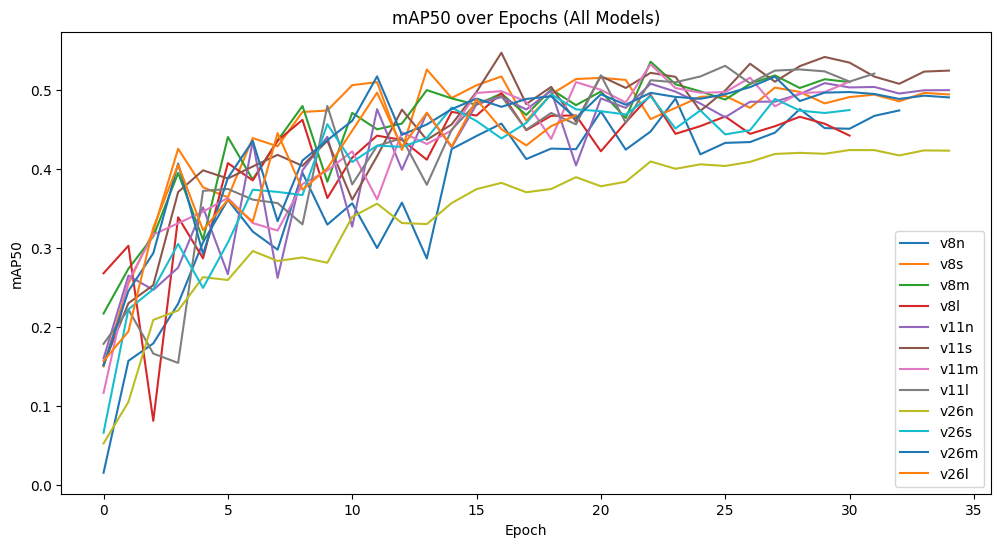

In [ ]:
# Compare and rank YOLOv8, YOLOv11, and YOLOv26 model variants across key detection metrics
import pandas as pd
import os
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/TBBR/results_revision"

runs = {
    # ---------- YOLOv8 ----------
    "v8n": "v8n_light_baseline_640_b16_adamw",
    "v8s": "v8s_640_b16_adamw_lr5e-4",
    "v8m": "v8m_640_b16_adamw_lr5e-4",
    "v8l": "v8l_640_b16_adamw_lr5e-4",

    # ---------- YOLOv11 ----------
    "v11n": "v11n_640_b16_adamw_lr5e-4",
    "v11s": "v11s_640_b16_adamw_lr5e-4",
    "v11m": "v11m_640_b16_adamw_lr5e-4",
    "v11l": "v11l_640_b16_adamw_lr5e-4",

    # ---------- YOLOv26 ----------
    "v26n": "v26n_640_b16_adamw_lr5e-4",
    "v26s": "v26s_640_b16_adamw_lr5e-4",
    "v26m": "v26m_640_b16_adamw_lr5e-4",
    "v26l": "v26l_640_b16_adamw_lr5e-4",
}

results = []

for name, folder in runs.items():
    run_dir = os.path.join(base_path, folder)
    csv_path = os.path.join(run_dir, "results.csv")

    if not os.path.exists(csv_path):
        print(f"Missing: {name}")
        continue

    df = pd.read_csv(csv_path)

    best_idx = df["metrics/mAP50(B)"].idxmax()
    best_row = df.loc[best_idx]

    precision = best_row["metrics/precision(B)"]
    recall = best_row["metrics/recall(B)"]

    results.append({
        "Model": name,
        "Best Epoch": int(best_row["epoch"]) if "epoch" in df.columns else int(best_idx),
        "Precision": precision,
        "Recall": recall,
        "mAP50": best_row["metrics/mAP50(B)"],
        "mAP50-95": best_row["metrics/mAP50-95(B)"],
        "F1": 2 * (precision * recall) / (precision + recall + 1e-9)
    })

summary_df = pd.DataFrame(results)

# ----------- RANKED TABLES -----------

rank_map50 = summary_df.sort_values("mAP50", ascending=False)
rank_map5095 = summary_df.sort_values("mAP50-95", ascending=False)

print("=== Ranked by mAP50 ===")
display(rank_map50)

print("\n=== Ranked by mAP50-95 ===")
display(rank_map5095)

# ----------- BAR PLOTS (RANKED) -----------

plt.figure(figsize=(12,5))
plt.bar(rank_map50["Model"], rank_map50["mAP50"])
plt.xticks(rotation=45)
plt.ylabel("mAP50")
plt.title("mAP50 Ranking (Highest to Lowest)")
plt.show()

plt.figure(figsize=(12,5))
plt.bar(rank_map5095["Model"], rank_map5095["mAP50-95"])
plt.xticks(rotation=45)
plt.ylabel("mAP50-95")
plt.title("mAP50-95 Ranking (Highest to Lowest)")
plt.show()

# ----------- EPOCH CURVES -----------

plt.figure(figsize=(12,6))

for name, folder in runs.items():
    run_dir = os.path.join(base_path, folder)
    csv_path = os.path.join(run_dir, "results.csv")

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        plt.plot(df["metrics/mAP50(B)"], label=name)

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("mAP50 over Epochs (All Models)")
plt.show()